In [1]:
from exact_lib import *
from sgd_lib import *
import logging
import warnings

# 1) Silence Lightning info logs (GPU summary, validation tables, etc.)
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)
logging.getLogger("lightning").setLevel(logging.ERROR)

# 2) Silence general warnings if you want
warnings.filterwarnings("ignore")

# 3) Silence "Seed set to X" from pl.seed_everything
pl.utilities.seed.log_seed = lambda *args, **kwargs: None

In [2]:
# ----------------- config -----------------
n_simulation = 30          # number of seeds (= number of instances in the pickle)
degs = [1, 2, 4, 6, 8]
input_dim = 3
n_instance = 100     # num_instances per seed
mult_noises = [0, 0.5]
grid_width = 3
epoch        = 5000
learning_rate = 0.1

# ----------------- paths ------------------
base_path = change_to_py_file_dir()
base      = os.path.join(base_path, "Comparision", "Data", "Shortest_path")

sols, edges, G = generate_all_feasible_solutions(grid_width=grid_width)
Z = np.vstack(sols)  # (K, m), m = number of edges = d_c

A, b = build_incidence_matrix_and_b(edges, G)
d_c = Z.shape[1]           # number of edges
d_p = len(G.nodes())       # number of nodes
model_list = ["MLE-0.001", "MLE-1", "MLE-100", "LST-0.001", "LST-1", "LST-100", "SPO", "DIO-0.001", "DIO-1", "DIO-100", "PAR-0.001", "PAR-0.1", "PAR-100"]

In [ ]:
# Exact solutions

exact_total_result = []

for deg in degs:
    for noise in mult_noises:
        for model_type in model_list:

            # ---- Parse model + eta ----
            if "-" in model_type:
                model_name, eta = model_type.split("-", 1)
                eta = float(eta)
            else:
                model_name = model_type
                eta = 1.0

            regret_result = []
            param_result = []

            solver = None  # build solver ONCE per model/deg/noise

            for seed in tqdm(range(n_simulation),
                             desc=f"Model {model_type} | deg={deg} noise={noise}",
                             colour="green"):

                random.seed(seed)
                np.random.seed(seed)

                # ---- Data for this seed ----
                x_train, y_train, x_test, y_test = load_shortest_path_setting_with_splits(
                    base, n_instance, input_dim, deg, noise, grid_width, seed
                )

                # ------------------------------
                # MLE
                # ------------------------------
                if model_name == "MLE":
                    if solver is None:
                        solver = MLEECPParam(
                            N=x_train.shape[0],
                            d_x=x_train.shape[1],
                            d_c=y_train.shape[1],
                            Z=sols,
                            eta=eta
                        )
                    res = solver.solve(x_train, y_train, verbose=False)
                    eval_res = solver.evaluate_regret(x_test, y_test, return_per_sample=False)

                # ------------------------------
                # LST
                # ------------------------------
                elif model_name == "LST":
                    if solver is None:
                        solver = LSTECPParam(
                            N=x_train.shape[0],
                            d_x=x_train.shape[1],
                            d_c=y_train.shape[1],
                            Z=sols,
                            eta=eta
                        )
                    res = solver.solve(x_train, y_train, verbose=False)
                    eval_res = solver.evaluate_regret(x_test, y_test, return_per_sample=False)

                # ------------------------------
                # SPO
                # ------------------------------
                elif model_name == "SPO":
                    if solver is None:
                        solver = SPOShortestPathParam(
                            N=x_train.shape[0],
                            d_x=x_train.shape[1],
                            d_c=y_train.shape[1],
                            d_p=d_p,   # known externally
                            A=A.T,
                            b=b
                        )
                    Zstar_train = compute_z_star_batch(y_train, Z)
                    res = solver.solve(x_train, y_train, Zstar_train, verbose=False)
                    eval_res = solver.evaluate_regret(
                        X_test=x_test, C_test=y_test, Z=Z, return_per_sample=False
                    )

                # ------------------------------
                # DIO
                # ------------------------------
                elif model_name == "DIO":
                    if solver is None:
                        solver = DIOECPParam(
                            N=x_train.shape[0],
                            d_x=x_train.shape[1],
                            d_c=y_train.shape[1],
                            Z=sols,
                            eta=eta
                        )
                    res = solver.solve(x_train, y_train, verbose=False)
                    eval_res = solver.evaluate_regret(x_test, y_test, return_per_sample=False)

                # ------------------------------
                # PAR (Pairwise ECPERM)
                # ------------------------------
                elif model_name == "PAR":
                    if solver is None:
                        solver = PairwiseECPERM(
                            X=x_train,
                            C=y_train,
                            Z=sols,
                            eta=eta,
                            tol=1e-9
                        )
                    res = solver.solve(verbose=False)
                    eval_res = solver.evaluate_regret(x_test, y_test, return_per_sample=False)

                # ---- Collect results ----
                regret_result.append(eval_res["avg_regret"])
                param_result.append(res["B"])

                # ---- Clean solver (each seed a new model) ----
                if solver is not None:
                    solver.M.dispose()
                    del solver
                    solver = None
                gc.collect()

            # ---- Save metadata for this (deg, noise, model) ----
            exact_total_result.append({
                "Deg": deg,
                "Noise": noise,
                "Modeltype": model_type,
                "Model": model_name,
                "Eta": eta,
                "regret": regret_result,
                "params": param_result
            })

# ---- Save pickle ----
save_path = os.path.join(base_path, "Data", "Score")
os.makedirs(save_path, exist_ok=True)

file_path = os.path.join(save_path, f"Shortest_path_exact_model_result_{grid_width}.pkl")

with open(file_path, "wb") as f:
    pickle.dump(exact_total_result, f)

print(f"Saved exact results → {file_path}")

In [ ]:
ckpt_root = Path(base_path)/ "Comparision" / "Result" / "Train" / "ckpt_dir"
log_dir  = Path(base_path) / "Result" / "Result" / "Train" / "CSVlogger"
ckpt_root.mkdir(parents=True, exist_ok=True)
log_dir.mkdir(parents=True, exist_ok=True)

# ----------------- graph / solver ---------
G      = define_graph(grid_width)
solver = ShortestPathSolver(G)

sgd_total_result = []

for deg in degs:
    for noise in mult_noises:
        for model_type in model_list:

            # ---- Parse model + eta ----
            if "-" in model_type:
                model_name, eta = model_type.split("-", 1)
                eta = float(eta)
            else:
                model_name = model_type
                eta = 1.0

            regret_result = []

            for seed in tqdm(range(n_simulation),
                             desc=f"Model {model_type} | deg={deg} noise={noise}",
                             colour="green"):

                pl.seed_everything(seed, workers=True)
                random.seed(seed)
                np.random.seed(seed)
                torch.manual_seed(seed)

                # ---- data ----
                y_train, x_test, y_test, train_dl, valid_dl, test_dl = sgd_load_shortest_path_setting_with_splits(base, n_instance, input_dim, deg, noise, grid_width, seed, batch_size=32)
                ckpt_dir = ckpt_root / f"{model_type}_seed_{seed}"
                # clean checkpoint directory for this seed
                shutil.rmtree(ckpt_dir, ignore_errors=True)
                ckpt_dir.mkdir(parents=True, exist_ok=True)
                log_dir.mkdir(parents=True, exist_ok=True)

                # ---- network (new net for each seed!) ----
                net = nn.Linear(input_dim, 2 * grid_width * (grid_width - 1))
                # ---- callbacks (recreated each seed) ----
                checkpoint_callback = ModelCheckpoint(
                    monitor="val_regret",                 # must match your logged metric name
                    dirpath=str(ckpt_dir),
                    filename="model-{epoch:02d}-{val_regret:.4f}",
                    mode="min",
                    save_top_k=1
                )

                early_stop_callback = EarlyStopping(
                    monitor="val_regret",
                    mode="min",
                    patience=100,
                    min_delta=0.0,
                    verbose=False
                )

                # ---- logger ----
                tb_logger = create_csv_logger(
                    log_dir=str(log_dir),
                    experiment_name=model_type,
                    seed=seed
                )

                # ---- model ----
                sols, edges, G = generate_all_feasible_solutions(grid_width=grid_width)
                if model_name == "MLE":
                    model = LSTModel(likelihood_ranking_loss, sols, net, solver, eta, lr=learning_rate, max_epochs=30)
                    model_class = LSTModel
                elif model_name == "LST":
                    model = LSTModel(listnet_loss, sols, net, solver, eta, lr=learning_rate, max_epochs=30)
                    model_class = LSTModel
                elif model_name == "SPO":
                    model = SPOModel(net, solver, lr=learning_rate, max_epochs=30)
                    model_class = SPOModel
                elif model_name == "DIO":
                    model = LSTModel(dio_loss, sols, net, solver, eta, lr=learning_rate, max_epochs=30)
                    model_class = LSTModel
                elif model_name == "PAR":
                    model = LSTModel(pairwise_loss, sols, net, solver, eta, lr=learning_rate, max_epochs=30)
                    model_class = LSTModel
                
                # ---- trainer ----
                trainer = pl.Trainer(
                    max_epochs=epoch,
                    min_epochs=5,
                    accelerator="auto",
                    devices=1,
                    callbacks=[checkpoint_callback, early_stop_callback],
                    logger=tb_logger,                 # keep CSV logger
                    enable_progress_bar=False,        # no tqdm bar
                    enable_model_summary=False,       # no model summary
                    log_every_n_steps=10**9,          # effectively never log per-step
                    num_sanity_val_steps=0,           # no sanity validation
                    inference_mode=True,
                    deterministic=True,
                )

                # trainer.validate(model, dataloaders=valid_dl)

                # ---- training ----
                trainer.fit(model, train_dataloaders=train_dl, val_dataloaders=valid_dl)

                # ---- load best model and test ----
                best_model_path = checkpoint_callback.best_model_path
                if not best_model_path:
                    raise RuntimeError(
                        f"No checkpoint saved for seed {seed}. "
                        "Check that 'val_regret' is logged in validation_step/validation_epoch_end."
                    )

                best_model = model_class.load_from_checkpoint(
                    checkpoint_path=best_model_path,
                    net=nn.Linear(input_dim, 2 * grid_width * (grid_width - 1)),
                    solver=solver,
                    lr=learning_rate,
                    max_epochs=epoch
                )

                test_result = trainer.test(best_model, dataloaders=test_dl, verbose=False)
                regret_result.append(test_result[0]["test_regret"])

            sgd_total_result.append({
                "Deg": deg,
                "Noise": noise,
                "Modeltype": model_type,
                "Model": model_name,
                "Eta": eta,
                "regret": regret_result
            })
            print(f"{model_type} regrets over {n_simulation} seeds:", regret_result)
            
# ---- Save pickle ----
save_path = os.path.join(base_path, "Data", "Score")
os.makedirs(save_path, exist_ok=True)

file_path = os.path.join(save_path, f"Shortest_path_sgd_model_result_{grid_width}.pkl")

with open(file_path, "wb") as f:
    pickle.dump(sgd_total_result, f)

print(f"Saved exact results → {file_path}")

In [3]:
save_path = os.path.join(base_path, "Data", "Score")
os.makedirs(save_path, exist_ok=True)

file_path = os.path.join(save_path, f"Shortest_path_sgd_model_result_{grid_width}.pkl")
with open(file_path, "rb") as f:
    sgd_total_result = pickle.load(f)  # list of dicts: {"seed": s, "x": X_s, "y": Y_s}

file_path = os.path.join(save_path, f"Shortest_path_exact_model_result_{grid_width}.pkl")
with open(file_path, "rb") as f:
    exact_total_result = pickle.load(f)  # list of dicts: {"seed": s, "x": X_s, "y": Y_s}

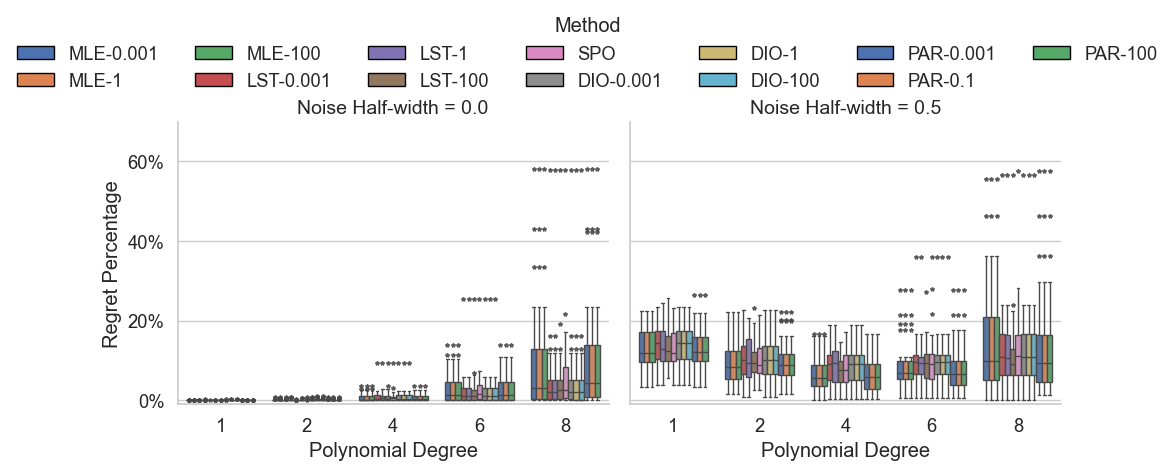

In [4]:
# save_path = os.path.join(base_path, "Results", "Score")
# os.makedirs(save_path, exist_ok=True)

# file_path = os.path.join(save_path, f"Shortest_path_model_result_{grid_width}.pkl")
# with open(file_path, "rb") as f:
#         total_result = pickle.load(f)  # list of dicts: {"seed": s, "x": X_s, "y": Y_s}
df = pd.DataFrame(exact_total_result)

df_long = (
    df
    .explode("regret")
    .rename(columns={"Deg": "Degree",
                     "Noise": "NoiseHalfWidth",
                     "Modeltype": "Method",
                     "regret": "Regret"})
)

df_long["Regret"] = df_long["Regret"].astype(float)

# ----------------------------------
# Seaborn setup
# ----------------------------------
sns.set(style="whitegrid", palette="deep", font_scale=1.2)
palette = sns.color_palette("deep")   # deep palette

methods = df_long["Method"].unique()
method_to_color = {m: palette[i % len(palette)] for i, m in enumerate(methods)}

# ----------------------------------
# Create the catplot
# ----------------------------------
g = sns.catplot(
    data=df_long,
    x="Degree",
    y="Regret",
    hue="Method",
    palette=method_to_color,
    col="NoiseHalfWidth",
    kind="box",
    height=4.5,
    aspect=1.1,
    sharey=True,
    legend=False,
    flierprops=dict(marker='*', markersize=3, linestyle='none', alpha=0.9)
)

# ----------------------------------
# Build LEGEND manually
# ----------------------------------
legend_handles = [
    Patch(facecolor=method_to_color[m], edgecolor='black', label=m)
    for m in methods
]

g.fig.legend(
    handles=legend_handles,
    title="Method",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.07),
    ncol=7,
    frameon=False
)

# ----------------------------------
# Y-axis formatting + titles
# ----------------------------------
for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
    ax.set_ylim(-0.01, 0.7)
    ax.set_ylabel("Regret Percentage")
    ax.set_xlabel("Polynomial Degree")

for ax, noise in zip(g.axes.flat, sorted(df_long["NoiseHalfWidth"].unique())):
    ax.set_title(f"Noise Half-width = {noise}", fontsize=14)

plt.subplots_adjust(top=0.80)


# Save figure
save_dir = os.path.join(base_path, "Results", "Figures")
os.makedirs(save_dir, exist_ok=True)

plt.savefig(
    os.path.join(save_dir, "sgd_model_sensitivity_analysis.png"),
    dpi=400,
    bbox_inches="tight"
)

plt.show()

In [5]:
def compute_var_cvar(regrets, alpha=0.90):
    """
    regrets: 1D array
    Returns: (VaR_alpha, CVaR_alpha)
    """
    r = np.sort(regrets)
    N = len(r)
    idx = int(np.floor(alpha * N)) - 1
    idx = max(0, min(idx, N - 1))
    
    var = r[idx]
    cvar = r[idx:].mean()
    return var, cvar

def summarize_results(results_list, method_name):
    rows = []
    for rec in results_list:
        regrets = np.asarray(rec["regret"], dtype=float)

        mean = regrets.mean()
        std = regrets.std(ddof=1)
        var90, cvar90 = compute_var_cvar(regrets, alpha=0.90)

        rows.append({
            "Method": method_name,
            "Deg": rec["Deg"],
            "Noise": rec["Noise"],
            "Modeltype": rec["Modeltype"],
            "Model": rec["Model"],
            "Eta": rec["Eta"],
            "Mean Regret Percentage": mean,
            "Std Regret Percentage": std,
            "VaR90 Percentage": var90,
            "CVaR90 Percentage": cvar90,
            "NSeeds": len(regrets),
        })
    return pd.DataFrame(rows)

df_sgd   = summarize_results(sgd_total_result, "SGD")
df_exact = summarize_results(exact_total_result, "Exact")

df_all = pd.concat([df_sgd, df_exact], ignore_index=True)
df_all = df_all.sort_values(["Deg", "Noise", "Model", "Eta", "Method"])

compare_table = df_all.pivot_table(
    index=["Deg", "Noise", "Model", "Eta"],
    columns="Method",
    values=["Mean Regret Percentage", "Std Regret Percentage", "VaR90 Percentage", "CVaR90 Percentage"]
)

compare_table = compare_table.reset_index()
# print(compare_table)

# Pivot to shape: index=(Deg, Noise, Model, Eta), columns=Method
pivot = df_all.pivot_table(
    index=["Deg", "Noise", "Model", "Eta"],
    columns="Method",
    values=["Mean Regret Percentage", "Std Regret Percentage", "VaR90 Percentage", "CVaR90 Percentage"]
)

# Flatten multiindex columns
pivot.columns = [f"{metric}_{method}" for metric, method in pivot.columns]
pivot = pivot.reset_index()

# Compute absolute differences (Exact - SGD)
pivot["Diff_Mean"]  = pivot["Mean Regret Percentage_Exact"] - pivot["Mean Regret Percentage_SGD"]
pivot["Diff_Std"]   = pivot["Std Regret Percentage_Exact"]  - pivot["Std Regret Percentage_SGD"]
pivot["Diff_VaR90"] = pivot["VaR90 Percentage_Exact"]      - pivot["VaR90 Percentage_SGD"]
pivot["Diff_CVaR90"] = pivot["CVaR90 Percentage_Exact"]    - pivot["CVaR90 Percentage_SGD"]

# Compute percent differences (relative to SGD)
pivot["PctDiff_Mean"]  = 100 * pivot["Diff_Mean"]  / pivot["Mean Regret Percentage_SGD"]
pivot["PctDiff_Std"]   = 100 * pivot["Diff_Std"]   / pivot["Std Regret Percentage_SGD"]
pivot["PctDiff_VaR90"] = 100 * pivot["Diff_VaR90"] / pivot["VaR90 Percentage_SGD"]
pivot["PctDiff_CVaR90"] = 100 * pivot["Diff_CVaR90"] / pivot["CVaR90 Percentage_SGD"]

# Clean up and show
summary_diff = pivot[[
    "Deg", "Noise", "Model", "Eta",
    "Mean Regret Percentage_SGD", "Mean Regret Percentage_Exact", "Diff_Mean", "PctDiff_Mean",
    "Std Regret Percentage_SGD",  "Std Regret Percentage_Exact",  "Diff_Std", "PctDiff_Std",
    "VaR90 Percentage_SGD",      "VaR90 Percentage_Exact",      "Diff_VaR90", "PctDiff_VaR90",
    "CVaR90 Percentage_SGD",     "CVaR90 Percentage_Exact",     "Diff_CVaR90", "PctDiff_CVaR90"
]]

print(summary_diff)



     Deg  Noise Model      Eta  Mean Regret Percentage_SGD  \
0      1    0.0   DIO    0.001                    0.002726   
1      1    0.0   DIO    1.000                    0.002203   
2      1    0.0   DIO  100.000                    0.010497   
3      1    0.0   LST    0.001                    0.002540   
4      1    0.0   LST    1.000                    0.001592   
..   ...    ...   ...      ...                         ...   
125    8    0.5   MLE  100.000                    0.457817   
126    8    0.5   PAR    0.001                    0.247463   
127    8    0.5   PAR    0.100                    0.229653   
128    8    0.5   PAR  100.000                    0.316118   
129    8    0.5   SPO    1.000                    0.489768   

     Mean Regret Percentage_Exact  Diff_Mean  PctDiff_Mean  \
0                    2.281864e-04  -0.002498    -91.629194   
1                    3.757093e-04  -0.001827    -82.942275   
2                    3.757093e-04  -0.010121    -96.420843   
3      

In [ ]:

# Choose metric to plot
metric = "Mean Regret Percentage"  # or "Std Regret Percentage", "VaR90 Percentage", "CVaR90 Percentage"

# Convert metrics to percentage
df_all["Mean Regret Percentage"] *= 100
df_all["Std Regret Percentage"]  *= 100
df_all["VaR90 Percentage"]      *= 100
df_all["CVaR90 Percentage"]     *= 100


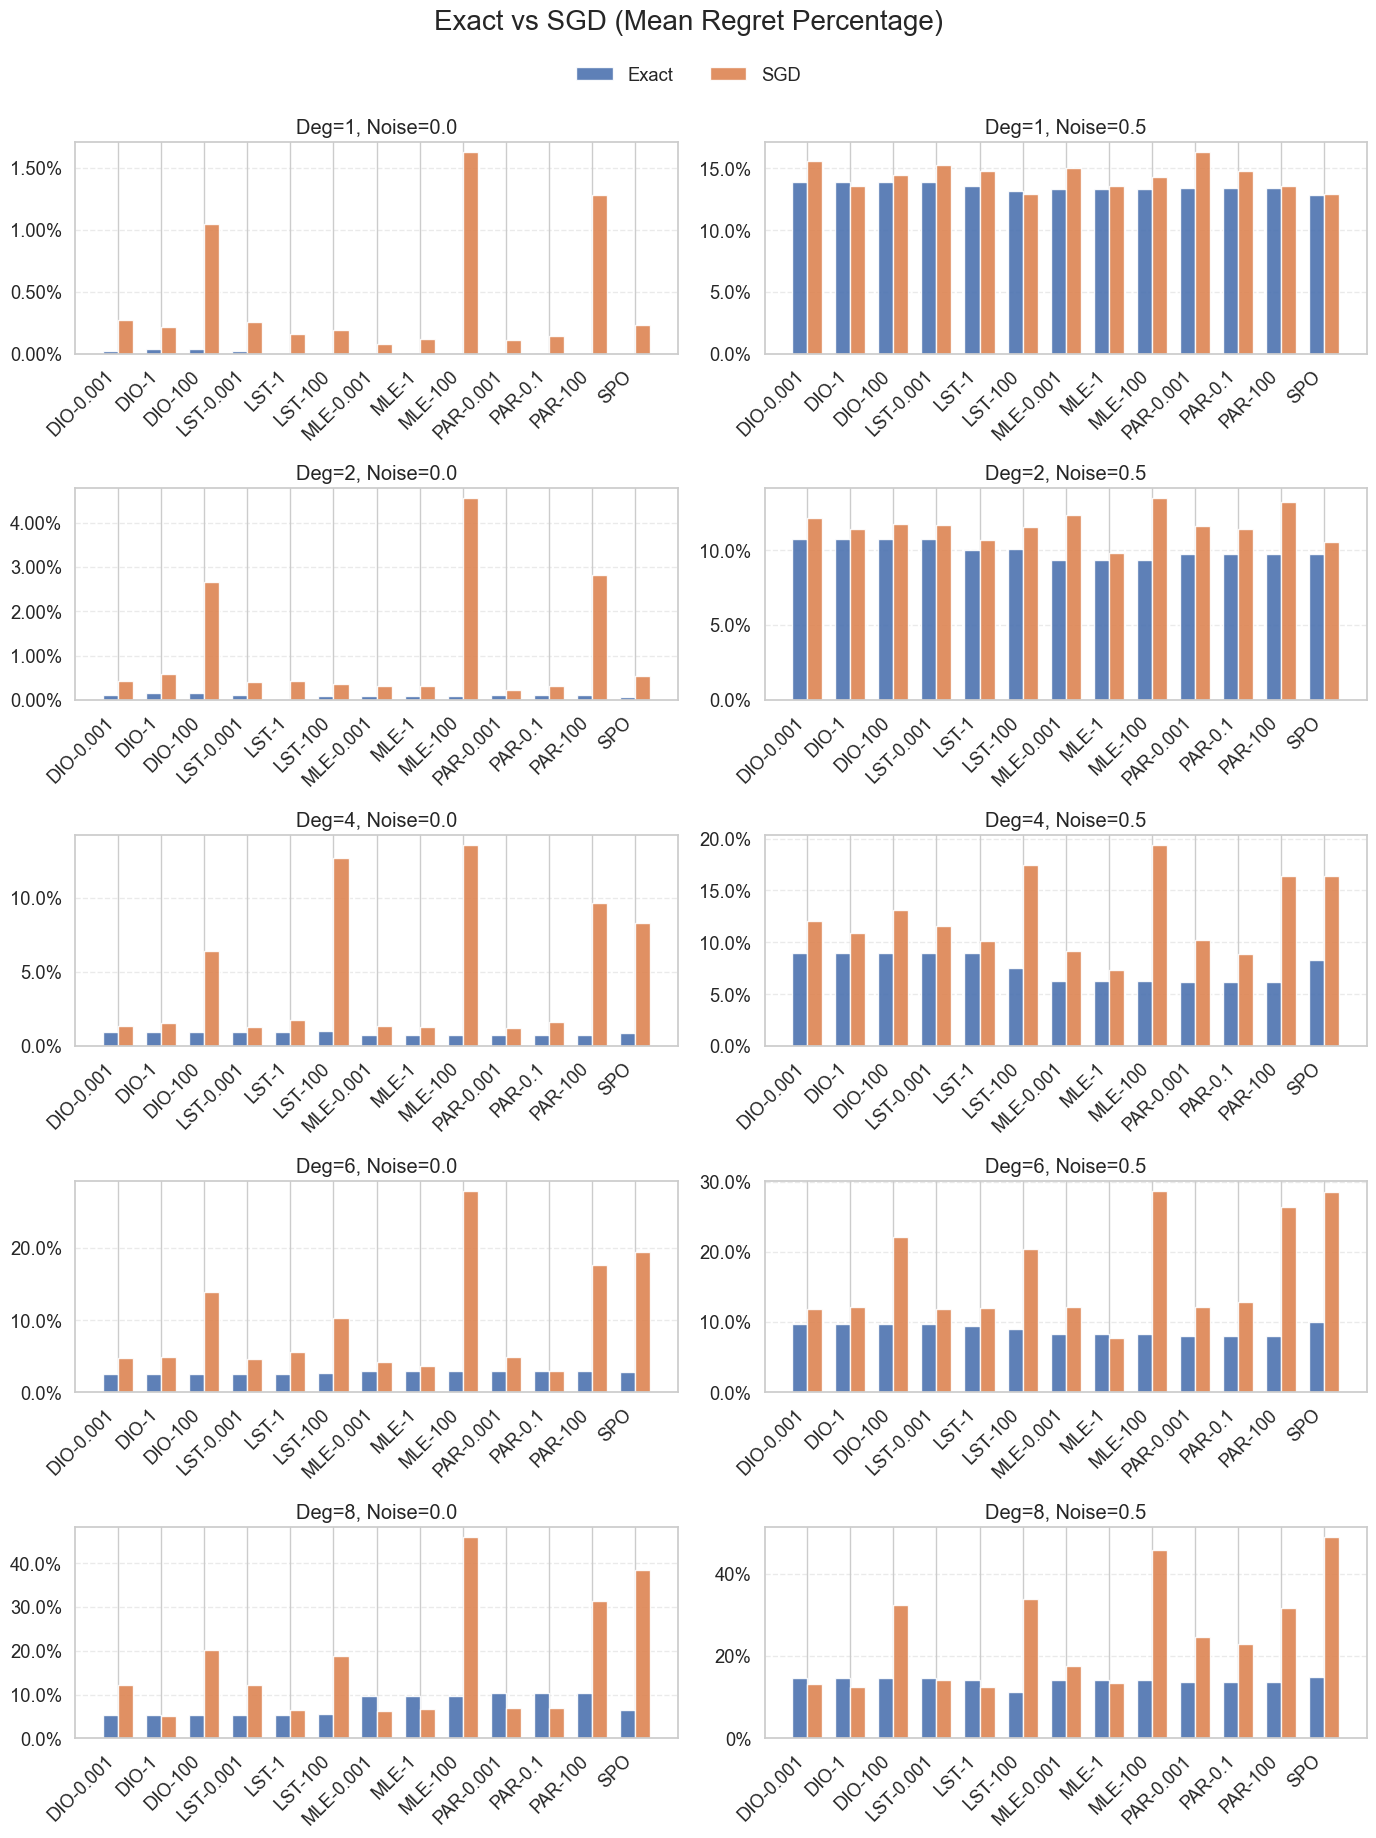

In [9]:

# Palette: deep seaborn
colors = sns.color_palette("deep", 2)

deg_values = sorted(df_all["Deg"].unique())
noise_values = sorted(df_all["Noise"].unique())  # should be 2

fig, axes = plt.subplots(
    nrows=len(deg_values),
    ncols=len(noise_values),
    figsize=(14, 20),
    sharey=False
)

axes = np.atleast_2d(axes)

# For global legend
legend_handles = None
legend_labels = None

for i, deg in enumerate(deg_values):
    for j, noise in enumerate(noise_values):
        
        ax = axes[i, j]
        
        df_sub = df_all[(df_all["Deg"] == deg) & (df_all["Noise"] == noise)].copy()
        if df_sub.empty:
            ax.set_title(f"No data (Deg={deg}, Noise={noise})")
            continue
        
        df_sub["Config"] = df_sub["Modeltype"]
        
        df_pivot = df_sub.pivot_table(
            index="Config",
            columns="Method",
            values=metric
        )
        
        methods = [m for m in ["Exact", "SGD"] if m in df_pivot.columns]
        
        x = np.arange(len(df_pivot.index))
        width = 0.35
        
        bar_containers = []
        
        for k, method in enumerate(methods):
            bars = ax.bar(
                x + (k - (len(methods)-1)/2) * width,
                df_pivot[method].values,
                width,
                color=colors[k],              # << deep seaborn colors
                alpha=0.9,
                label=method
            )
            bar_containers.append(bars)
        
        ax.set_xticks(x)
        ax.set_xticklabels(df_pivot.index, rotation=45, ha="right")
        
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())
        ax.set_title(f"Deg={deg}, Noise={noise}")
        ax.grid(axis="y", linestyle="--", alpha=0.4)
        
        # Save legend handles for global legend
        if legend_handles is None:
            legend_handles = [bc.patches[0] for bc in bar_containers]
            legend_labels = methods


# ---------------------------
# Global title + Legend
# ---------------------------

fig.suptitle(f"Exact vs SGD ({metric})", fontsize=20, y=0.92)

fig.legend(
    legend_handles,
    legend_labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.9),    # Under title
    ncol=2,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()
